##load data

In [17]:
import pandas as pd

df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


##Basic Understanding

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [19]:
df.describe()

,Unnamed: 0
count,1.407328e+06
mean,7.072454e+05
std,4.081009e+05
min,0.000000e+00
25%,3.538128e+05
50%,7.072395e+05
75%,1.060710e+06
max,1.413848e+06


##TEXT LENGTH ANALYSIS

In [20]:
df["headline_length"] = df["headline"].str.len()

df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

##Visualization

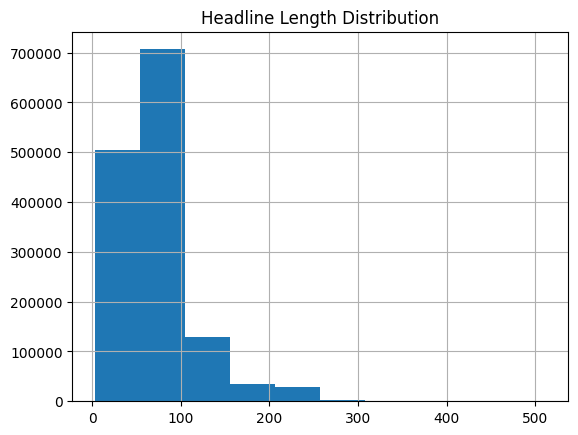

In [21]:
import matplotlib.pyplot as plt

df["headline_length"].hist()
plt.title("Headline Length Distribution")
plt.show()

##ARTICLES PER PUBLISHER

In [22]:
publisher_counts = df["publisher"].value_counts()
publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

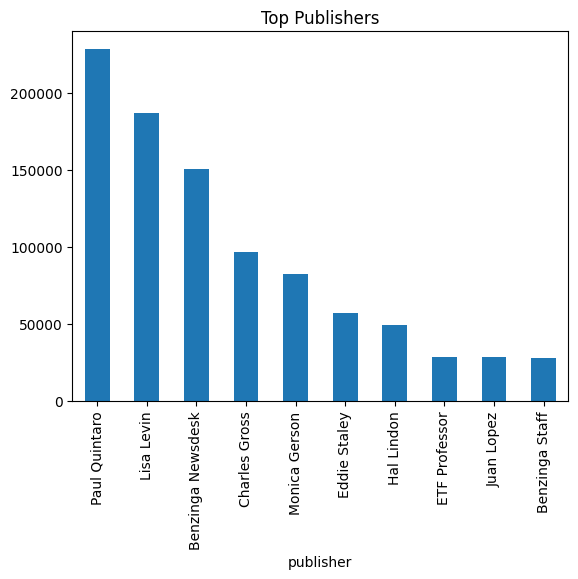

In [23]:
publisher_counts.head(10).plot(kind='bar')
plt.title("Top Publishers")
plt.show()

##TIME ANALYSIS this used as a data-cleaning challenge

In [24]:
df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
    utc=True
)

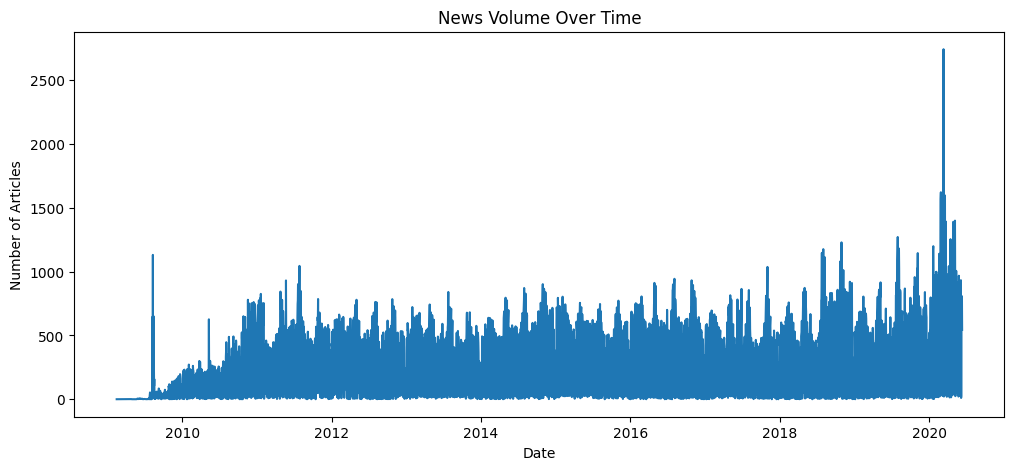

In [25]:
df["date_only"] = df["date"].dt.date

daily_counts = df.groupby("date_only").size()

daily_counts.plot(figsize=(12,5))

plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

##TIME OF DAY ANALYSIS

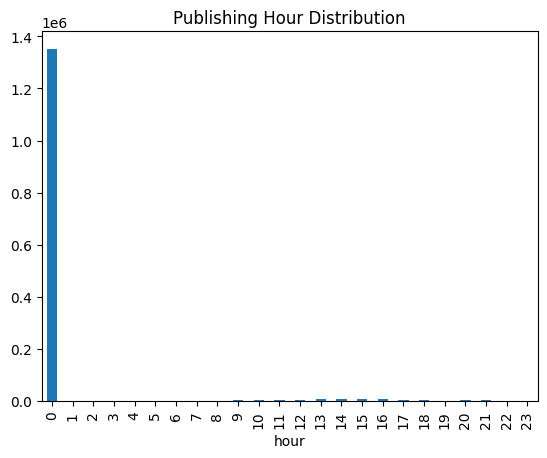

In [26]:
df["hour"] = df["date"].dt.hour

df["hour"].value_counts().sort_index().plot(kind='bar')

plt.title("Publishing Hour Distribution")
plt.show()

In [1]:
from sklearn.feature_extraction.text import CountVectorizer

In [12]:


import pandas as pd

df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df["headline"])

words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

In [13]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df["headline"])

word_df = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

word_df = pd.DataFrame({
    "word": word_df,
    "count": counts
})

word_df = word_df.sort_values(
    by="count",
    ascending=False
)

word_df

,word,count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


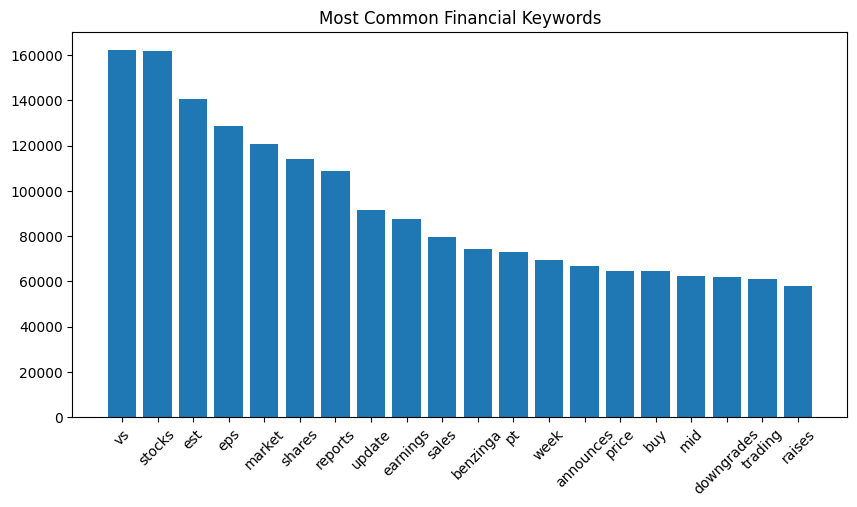

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    word_df["word"],
    word_df["count"]
)

plt.xticks(rotation=45)

plt.title("Most Common Financial Keywords")

plt.show()

### Keyword Analysis Insight

Common financial keywords such as "stocks", "earnings", "market", and "shares" appeared frequently in news headlines, indicating strong focus on company performance and market activity.

In [2]:
from wordcloud import WordCloud

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud

In [8]:
import pandas as pd

df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

print(df.head())

   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00 

In [10]:
text = " ".join(
    df["headline"].sample(20000, random_state=1)
)

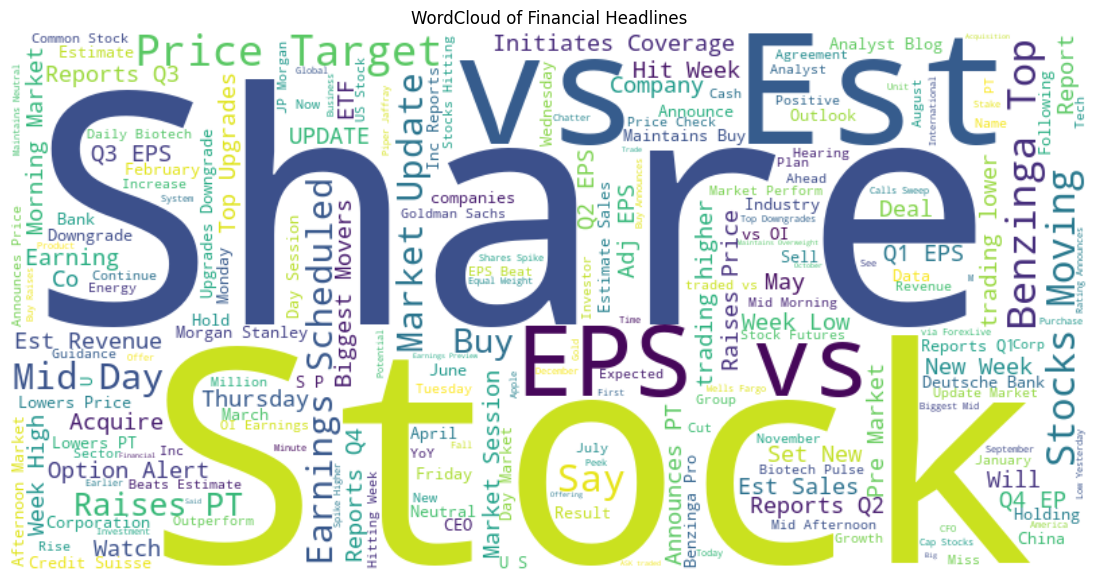

In [12]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)
plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("WordCloud of Financial Headlines")

plt.show()

### Word Cloud Insight

The word cloud highlights dominant themes within the financial news dataset. Terms related to stock performance, earnings, analyst ratings, and market movement were highly represented.

In [13]:
from nltk.sentiment import SentimentIntensityAnalyzer

In [17]:
df_sample = df.sample(50000, random_state=1)

In [18]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df_sample["sentiment"] = df_sample["headline"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

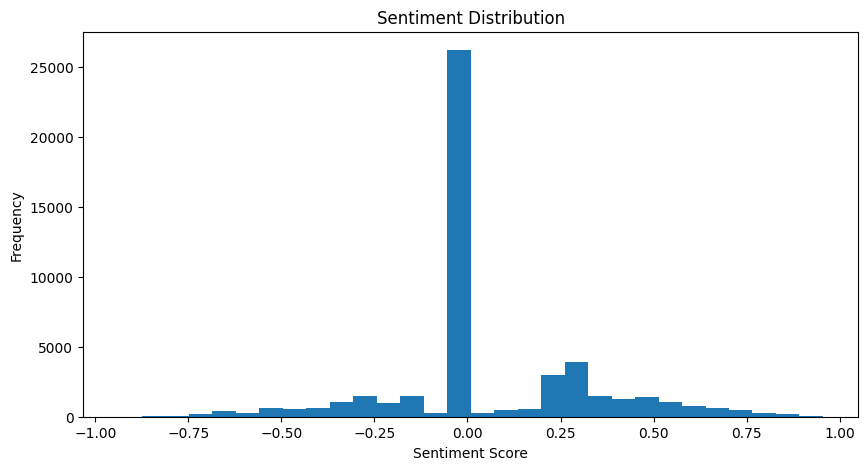

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df_sample["sentiment"], bins=30)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")

plt.show()

### Sentiment Distribution Insight

Most headlines were clustered around neutral sentiment scores, while fewer headlines showed strongly positive or strongly negative sentiment. This reflects the generally informational tone of financial reporting.